<a href="https://colab.research.google.com/github/MokuaEnock/data-student/blob/main/Copy_of_Connecting_to_SQL_Database.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="green">*To start working on this notebook, or any other notebook that we will use in the Moringa Data Science Course, we will need to save our own copy of it. We can do this by clicking File > Save a Copy in Drive. We will then be able to make edits to our own copy of this notebook.*</font>

## **Introduction**

Now that you've gotten a brief introduction to SQL, its time to get some hands-on practice connecting to a database and executing some queries.

## Objectives

You will be able to:

* Connect to a SQLite database through the `sqlite3` magic commands
* View information about database tables and column names
* Retrieve all information from a SQL table

## Download the Database

SQLite databases are stored as files on disk. The one we will be using in this lesson is called `data.sqlite`.

* Download the database from [here](https://drive.google.com/file/d/1ho0tp9F94p9k2R-sNML8uIx0HXXxvzEj/view)

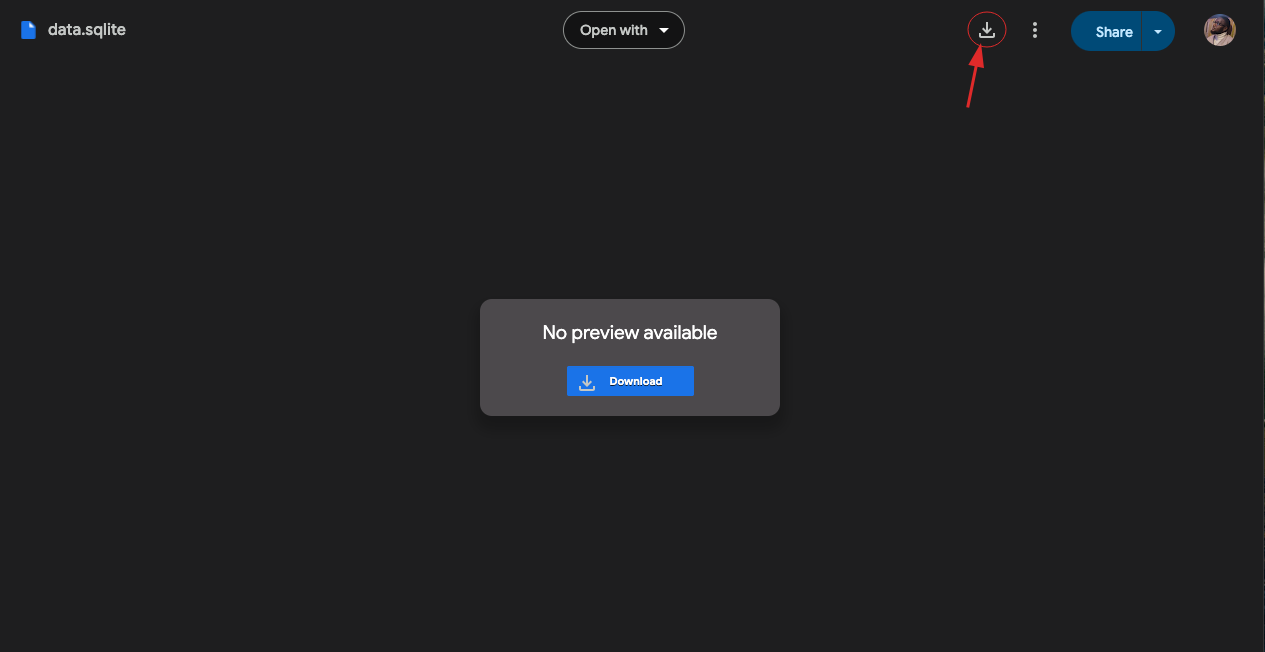

* Once you've downloaded the database, open your google drive and create a folder called `Databases`.

* Next upload the database you downloaded earlier inside the `Database` you just created.

## Mounting Google Drive in Colab


In [ ]:
!pip install -U ipython-sql
!pip install prettytable==2.5.0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Google Colab allows direct access to your Google Drive, enabling you to easily load files, including databases. Let’s start by mounting your Google Drive.

* On the left toolbar of Colab, click on the folder icon

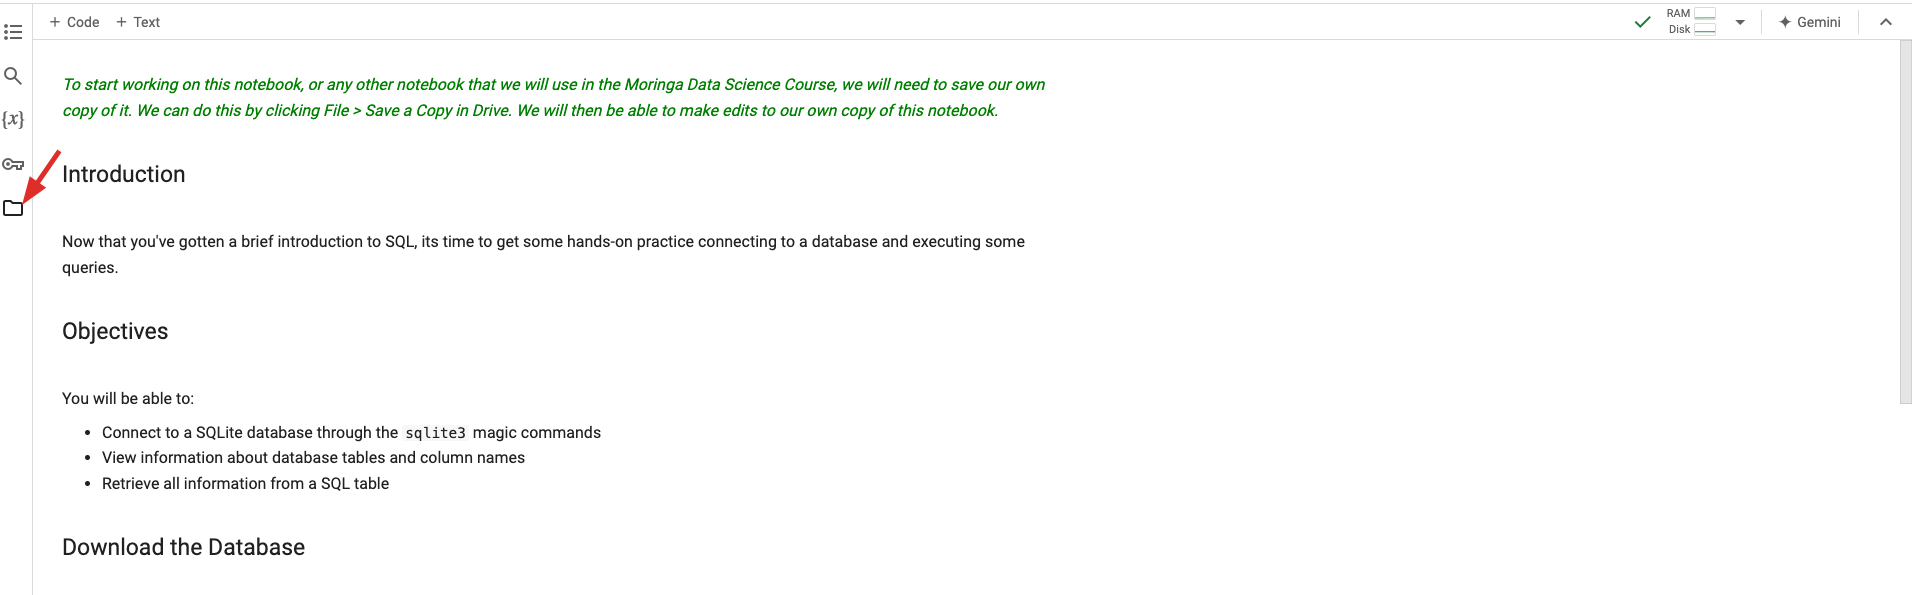

* When the icon is clicked, a pane will open up.At the top of the file explorer panel, you’ll see a button labeled “Mount Drive”.

* Click the “Mount Drive” button.

* After clicking “Mount Drive,” a pop-up will appear asking you to authorize Google Colab to access your Google Drive.

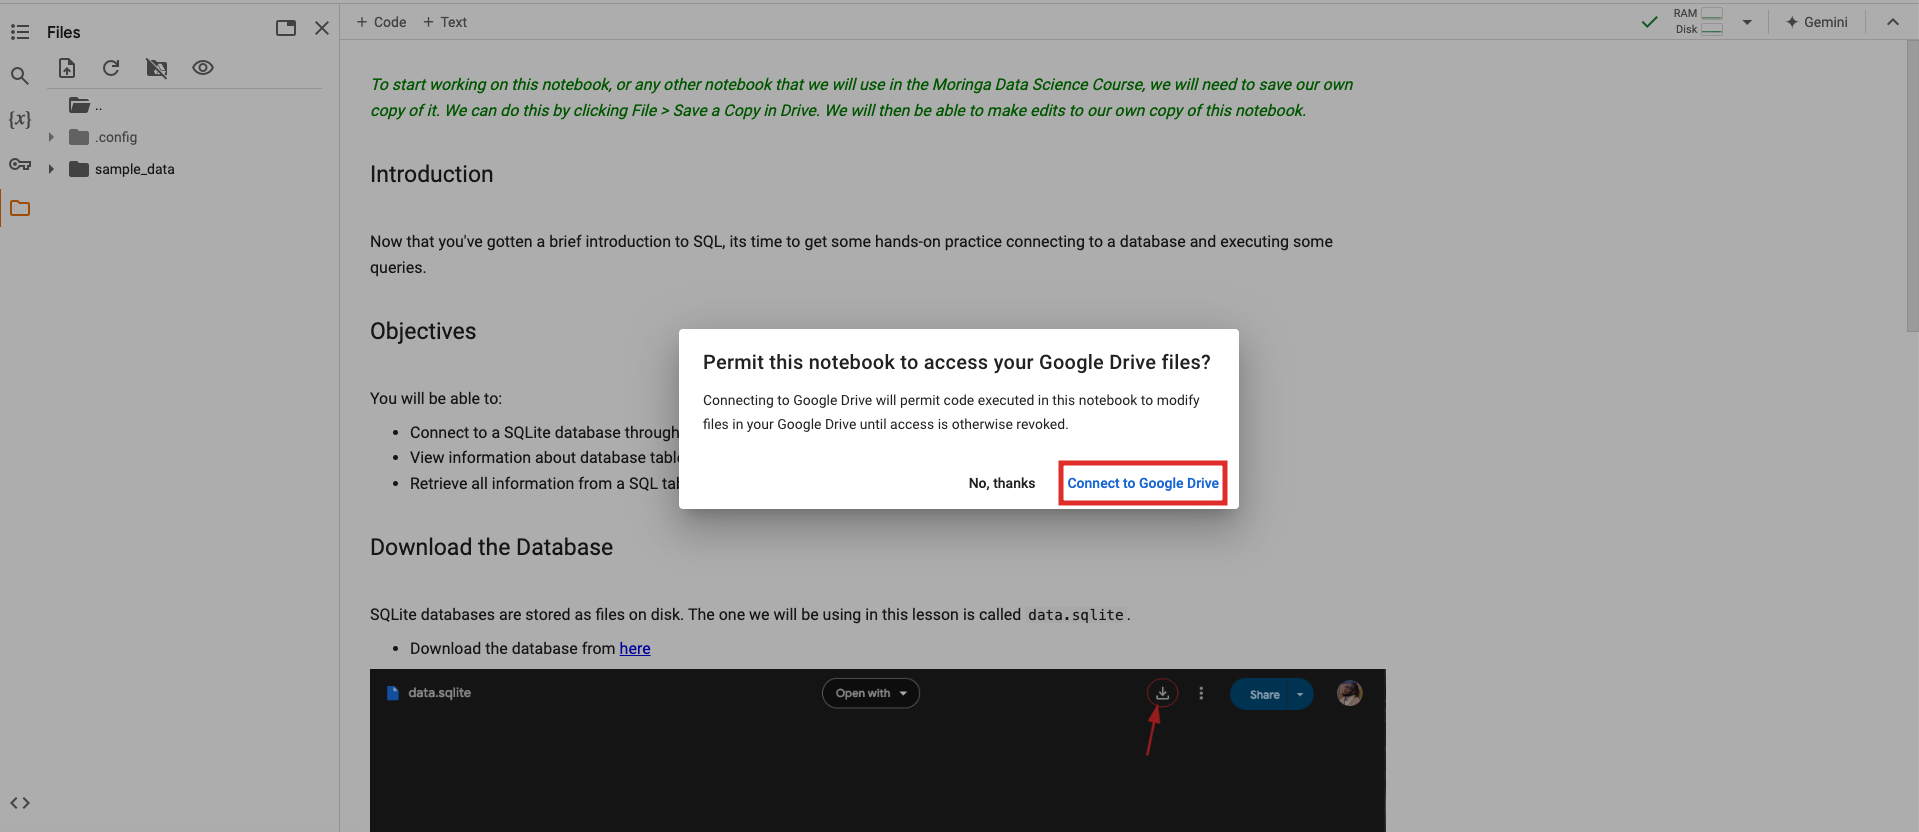

* Click “Connect to Google Drive”, and follow the authentication prompts.

* After the drive is mounted, you’ll see a new folder named “drive” in the file explorer panel.

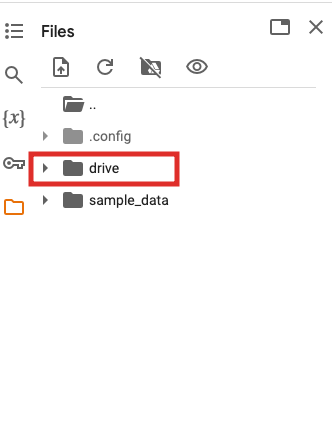

* You can now navigate through your Google Drive directly from Colab’s file explorer and access your files, including your database.

*





> Note: You have to Mount your google drive everytime you open the colab notebook



## **Connecting to the Database**

### SQL Magic Commands

In this course, as we are learning SQL we are going to be using SQL Commands.

SQL Magic commands are special shortcuts in Google Colab that let you run SQL queries directly within your notebook without needing to use a separate database program.

Instead of writing a lot of extra code to connect to and run SQL on a database, you just add a simple command (`%sql` or `%%sql`) before your SQL query, and Colab will handle the rest. This makes it easy to fetch data, create tables, or run any SQL commands directly inside your Python notebook, saving you time and effort.

### **Load SQL Extention**

The SQL extension in Google Colab helps us run SQL queries directly in our notebook without needing to write additional Python code for database connections. It makes it easy to:

* Connect to a database.
* Write and execute SQL queries directly.
* View the results of SQL queries in the same notebook.


In [ ]:
# We will first load the sql extension into our environment
#
%load_ext sql

### Connect to the Database

* After mounting, navigate through the directory structure under the "drive" folder.
* You’ll see two main directories: My Drive and Shared drives. Expand My Drive to access your personal Google Drive files.
* Navigate to where the Databases folder(the one you created earlier) is

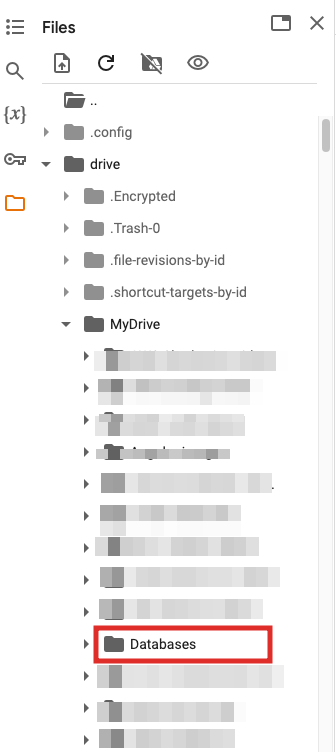

* Look for your SQL database file (e.g., data.sqlite) by clicking through your folders.

* Once you locate your database file, right-click on the file and select Copy Path from the context menu.


The syntax for connecting to our database will look something like this:


```
%sql sqlite:////content/drive/MyDrive/Databases/data.sqlite

```

In this case, `sqlite:///` is the connection string for SQLite databases.


In [ ]:
#  Connect to our in sqlite database
# NB: This database will cease to exist as soon as the database connection is closed
%sql sqlite:////content/drive/MyDrive/Databases/data.sqlite

## **View the List of Tables**

Now that we have successfully connect to the database, let's look at tables inside of the database.

Any given database can contain multiple tables.

In colab we run every SQL query by prefixing it with %%sql. For example, to view the tables in the database, you can run:



```
%%sql
SELECT name FROM sqlite_master WHERE type='table';
```
**Breakdown of what the code above does**

* `%%sql`: This is a magic command in Google Colab that allows you to run SQL queries directly in the notebook. It tells the notebook that the following cell contains SQL code.

* `SELECT name FROM sqlite_master`: This part of the SQL query retrieves the name column from the sqlite_master table. The sqlite_master table is a system table in SQLite that stores information about all database objects (tables, indexes, views, and triggers).

* `WHERE type='table'`: This condition filters the results to only return objects that are of type table. The sqlite_master table also contains information about other objects like indexes or views, so this condition ensures that only table names are returned.



> NOTE: Don't worry if this does not make sense right now. We'll cover all the SQL syntax in the coming lessons

**Output:**
The result of this query will be a list of the names of all the tables in the current SQLite database. This is useful when you want to know what tables are available in the database before running further queries.




In [ ]:
%%sql
-- SET style plain;
SELECT name FROM sqlite_master WHERE type='table';

 * sqlite:////content/drive/MyDrive/Databases/data.sqlite
Done.


name


### Selecting All Data from the `offices` Table

If we want to get all information about the `offices` table, we might do something like this (`*` means all columns):



```
%%sql
SELECT * FROM offices;
```



In [ ]:
# Get all the information about the offices table

%%sql
SELECT * FROM offices;

 * sqlite:////content/drive/MyDrive/Databases/data.sqlite
(sqlite3.OperationalError) no such table: offices
[SQL: SELECT * FROM offices;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


### Viewing the Column Names from the `offices` Table

To view the column names of the offices table in your SQLite database, you can use the following SQL query:


```
%%sql
PRAGMA table_info(offices);
```
**Explanation:**

`PRAGMA table_info(offices)`: This is a special SQLite command that provides information about the structure of the office table, including column names, data types, and other metadata like whether a column is part of the primary key or allows NULL values.

> Note: This is a handy way to inspect the structure of a table and view its column names.





In [ ]:
%%sql
PRAGMA table_info(offices);

 * sqlite:////content/drive/MyDrive/Databases/data.sqlite
Done.


cid,name,type,notnull,dflt_value,pk


**Output:**

This query will return a table with the following columns:

* **`cid`**: The index of the column (starting from 0).

* **`name`**: The name of the column (what you’re interested in).

* **`type`**: The data type of the column (e.g., INTEGER, TEXT).

* **`notnull`**: Whether the column can be NULL (0 means it allows NULL, 1 means it doesn't).

* **`dflt_value`**: The default value for the column, if any.

* **`pk`**: Whether the column is part of the primary key (1 means it is, 0 means it isn’t).
